In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [40]:
data_logical_filter = pd.read_csv("data/dataset_logical_filter.csv")
data_price_ratio = pd.read_csv("data/dataset_Price_Ratio_.20.csv")
dfLogical = pd.DataFrame(data_logical_filter)
dfPrice = pd.DataFrame(data_price_ratio)
dfLogical

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
293,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
294,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
295,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
296,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [41]:
###### Convert categorical text columns into numbers for model training

In [42]:
dfLogical = pd.get_dummies(dfLogical, columns=['Fuel_Type', 'Seller_Type'], drop_first=True, dtype=int)

dfLogical['Transmission'] = dfLogical['Transmission'].map({'Manual': 0, 'Automatic': 1})
dfLogical.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual
0,2014,3.35,5.59,27000,0,0,0,1,0
1,2013,4.75,9.54,43000,0,0,1,0,0
2,2017,7.25,9.85,6900,0,0,0,1,0
3,2011,2.85,4.15,5200,0,0,0,1,0
4,2014,4.60,6.87,42450,0,0,1,0,0


In [43]:
def train_linear_model(dataframe, target_column):
    X = dataframe.drop(target_column, axis=1)
    y = dataframe[target_column].values.reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model, X_test, y_test

In [44]:
model_logical, X_test_logical, y_test_logical = train_linear_model(dfLogical, 'Selling_Price')

In [45]:
y_pred_logical = model_logical.predict(X_test_logical)

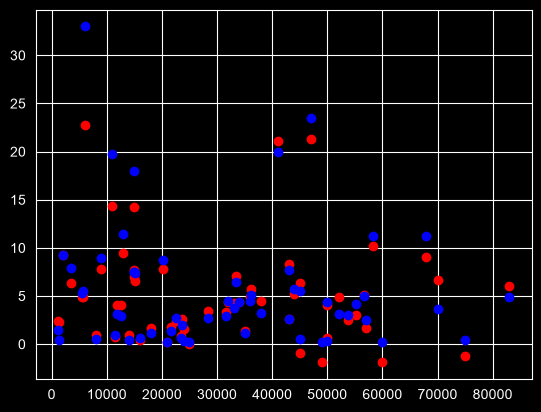

In [46]:
plt.scatter(X_test_logical.Kms_Driven, y_pred_logical, color='red')
plt.scatter(X_test_logical.Kms_Driven, y_test_logical, color='blue')

In [47]:
#######errore and score Logical model

In [48]:
mae = mean_absolute_error(y_test_logical, y_pred_logical)
mse = mean_squared_error(y_test_logical, y_pred_logical)
r2 = r2_score(y_test_logical, y_pred_logical)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.9085765499932663
MAE: 1.12028924864956
MSE: 3.5622278239045237


In [50]:
dfPrice = pd.get_dummies(dfPrice, columns=['Fuel_Type', 'Seller_Type'], drop_first=True, dtype=int)

dfPrice['Transmission'] = dfPrice['Transmission'].map({'Manual': 0, 'Automatic': 1})
dfPrice.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Transmission,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual
0,2014,3.35,5.59,27000,0,0,0,1,0
1,2013,4.75,9.54,43000,0,0,1,0,0
2,2017,7.25,9.85,6900,0,0,0,1,0
3,2011,2.85,4.15,5200,0,0,0,1,0
4,2014,4.60,6.87,42450,0,0,1,0,0


In [52]:
model_price, X_test_price, y_test_price = train_linear_model(dfPrice, 'Selling_Price')
y_pred_price = model_logical.predict(X_test_price)


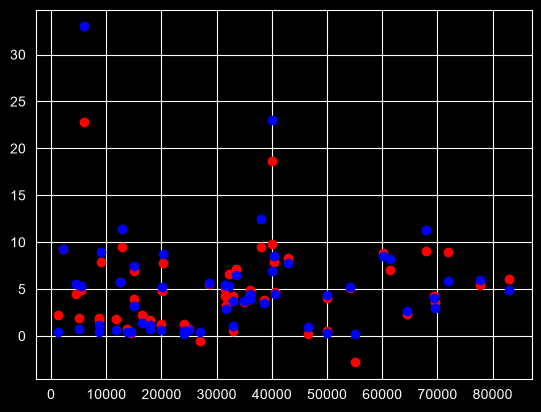

In [53]:
plt.scatter(X_test_price.Kms_Driven, y_pred_price, color='red')
plt.scatter(X_test_price.Kms_Driven, y_test_price, color='blue')

In [55]:
mae = mean_absolute_error(y_test_price, y_pred_price)
mse = mean_squared_error(y_test_price, y_pred_price)
r2 = r2_score(y_test_price, y_pred_price)

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

R2 Score: 0.8883937863366288
MAE: 1.0384533418681865
MSE: 3.2879841522696034
